# Freight Rate Prediction — Exploratory Data Analysis

This notebook verifies the known data-quality issues and explores the signals used by the temporal LightGBM model. All figures are written to `report/`, and the final cell assembles `report/report.pdf`.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
REPORT = ROOT / 'report'
REPORT.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / 'src'))
from clean import load_and_clean

plt.style.use('seaborn-v0_8-whitegrid')
raw = pd.read_csv(ROOT / 'data' / 'train_test.csv', parse_dates=['date'])
data = load_and_clean(ROOT / 'data' / 'train_test.csv')
data['rate_per_mile'] = data['posted_rate'] / data['distance']
print(f'Rows: {len(raw):,} | Date range: {raw.date.min().date()} to {raw.date.max().date()}')

Rows: 48,000 | Date range: 2025-01-01 to 2025-10-31


## Data quality audit

In [2]:
null_counts = raw.isna().sum().loc[lambda values: values.gt(0)].rename('null_count').to_frame()
negative_weights = raw.loc[raw['weight'].lt(0), ['load_id', 'equipment', 'weight']].head(10)
print(f'Negative weights before cleaning: {(raw.weight < 0).sum():,}')
print(f'Negative weights after cleaning: {(data.weight < 0).sum():,}')
print(f'Rows lost during cleaning: {len(raw) - len(data):,}')
display(null_counts)
display(negative_weights)

Negative weights before cleaning: 292
Negative weights after cleaning: 0
Rows lost during cleaning: 0


,null_count
weight,300
market_index,374


,load_id,equipment,weight
68,TR-000069,Reefer,-36559.0
204,TR-000205,Dry Van,-26670.0
206,TR-000207,Reefer,-20003.0
225,TR-000226,Reefer,-23981.0
376,TR-000377,Dry Van,-41397.0
446,TR-000447,Reefer,-37215.0
495,TR-000496,Dry Van,-31214.0
641,TR-000642,Dry Van,-41023.0
806,TR-000807,Dry Van,-28320.0
1093,TR-001094,Dry Van,-25153.0


## Rate-per-mile distribution and outliers

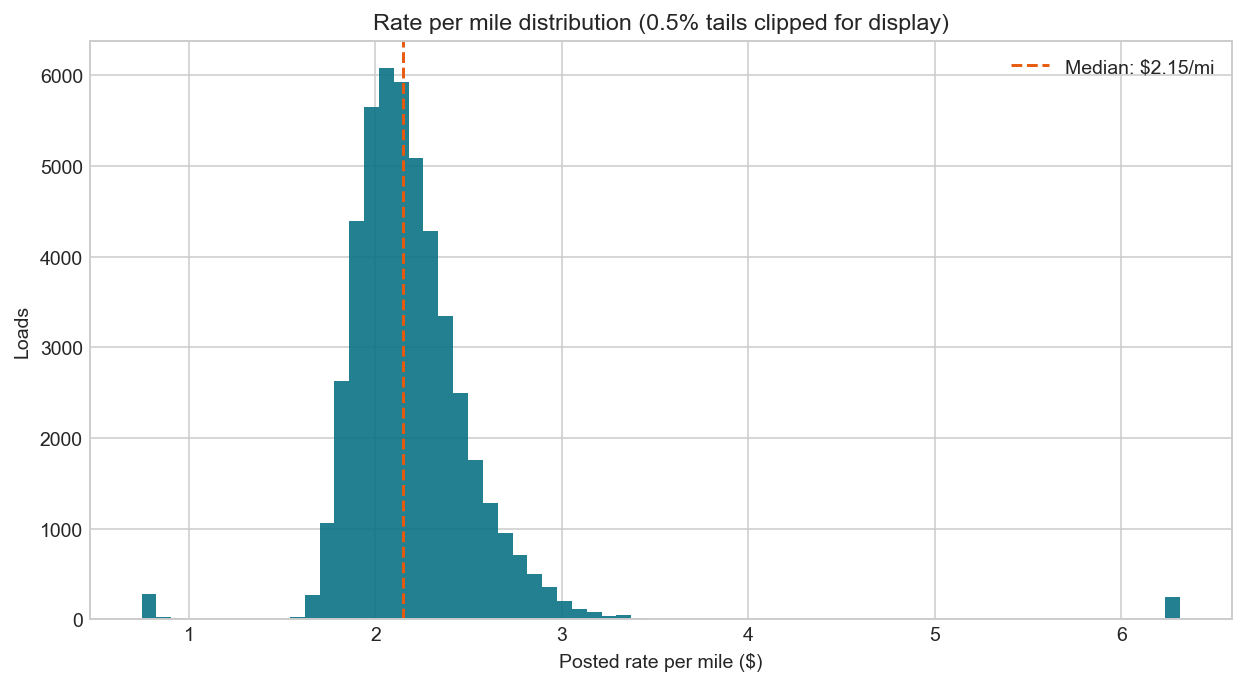

0.000     0.333709
0.005     0.746195
0.500     2.145348
0.995     6.314326
1.000    14.125294
Name: rate_per_mile, dtype: float64

In [3]:
rpm_bounds = data['rate_per_mile'].quantile([0.005, 0.995])
figure, axis = plt.subplots(figsize=(9, 5), dpi=140)
axis.hist(data['rate_per_mile'].clip(*rpm_bounds), bins=70, color='#0B7285', alpha=0.9)
axis.axvline(data['rate_per_mile'].median(), color='#E8590C', linestyle='--', label=f"Median: ${data['rate_per_mile'].median():.2f}/mi")
axis.set(title='Rate per mile distribution (0.5% tails clipped for display)', xlabel='Posted rate per mile ($)', ylabel='Loads')
axis.legend()
figure.tight_layout()
figure.savefig(REPORT / 'rate_per_mile_distribution.png', bbox_inches='tight')
plt.show()
display(data['rate_per_mile'].quantile([0, .005, .5, .995, 1]).rename('rate_per_mile'))

## Monthly seasonality

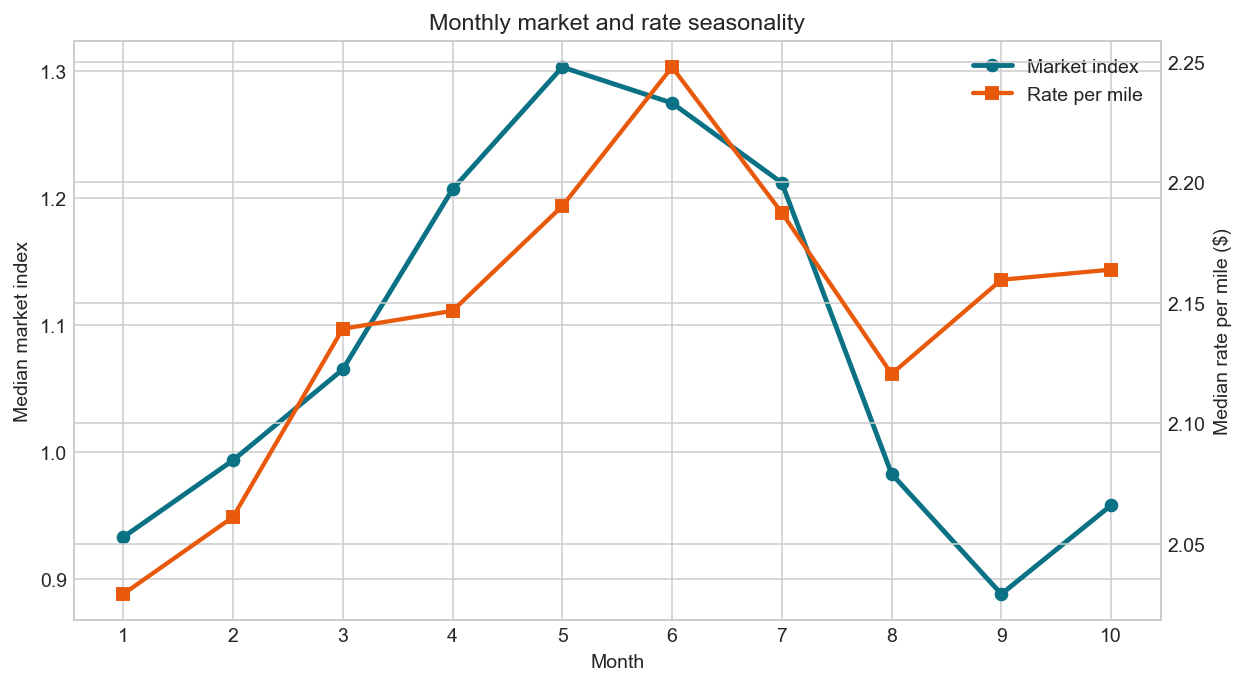

,market_index,rate_per_mile
month,,
1,0.933,2.029
2,0.993,2.061
3,1.065,2.139
4,1.207,2.147
5,1.303,2.190
6,1.275,2.248
7,1.212,2.187
8,0.983,2.121
9,0.888,2.160


In [4]:
monthly = data.assign(month=data.date.dt.month).groupby('month').agg(market_index=('market_index', 'median'), rate_per_mile=('rate_per_mile', 'median'))
figure, left = plt.subplots(figsize=(9, 5), dpi=140)
right = left.twinx()
left.plot(monthly.index, monthly.market_index, marker='o', linewidth=2.5, color='#0B7285', label='Market index')
right.plot(monthly.index, monthly.rate_per_mile, marker='s', linewidth=2.2, color='#E8590C', label='Rate per mile')
left.set(title='Monthly market and rate seasonality', xlabel='Month', ylabel='Median market index')
right.set_ylabel('Median rate per mile ($)')
left.set_xticks(monthly.index)
lines = left.lines + right.lines
left.legend(lines, [line.get_label() for line in lines], loc='best')
figure.tight_layout()
figure.savefig(REPORT / 'monthly_seasonality.png', bbox_inches='tight')
plt.show()
display(monthly.round(3))

## Equipment price tiers

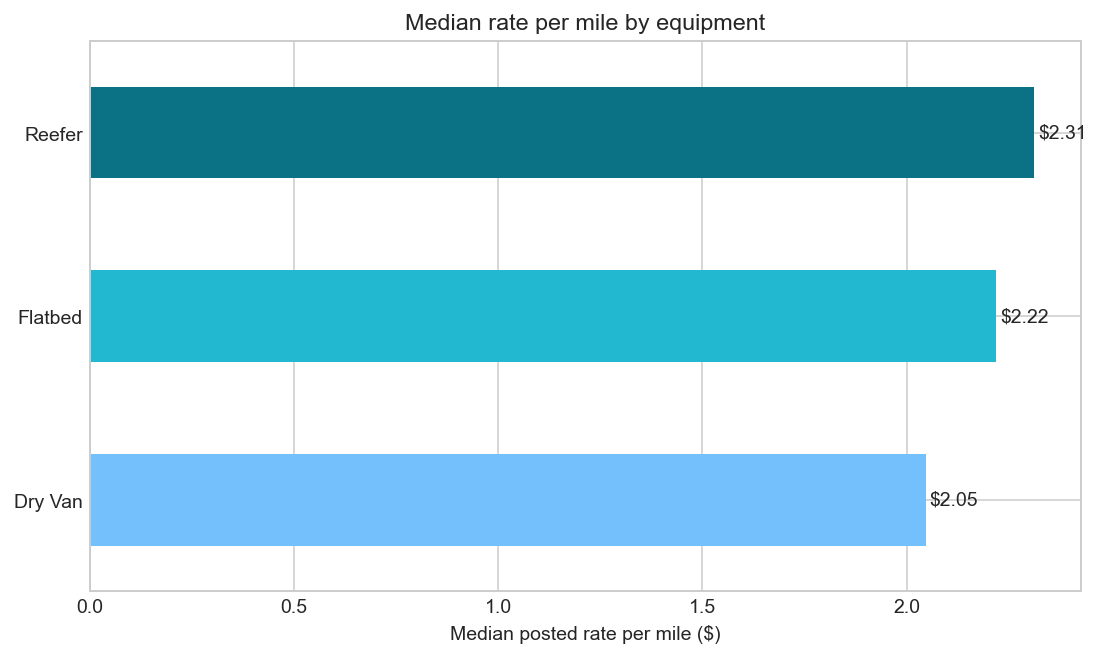

equipment
Dry Van    2.046
Flatbed    2.220
Reefer     2.312
Name: median_rate_per_mile, dtype: float64

In [5]:
equipment_tiers = data.groupby('equipment')['rate_per_mile'].median().sort_values()
figure, axis = plt.subplots(figsize=(8, 4.8), dpi=140)
equipment_tiers.plot.barh(ax=axis, color=['#74C0FC', '#22B8CF', '#0B7285'])
axis.set(title='Median rate per mile by equipment', xlabel='Median posted rate per mile ($)', ylabel='')
for patch in axis.patches:
    axis.text(patch.get_width() + 0.01, patch.get_y() + patch.get_height()/2, f'${patch.get_width():.2f}', va='center')
figure.tight_layout()
figure.savefig(REPORT / 'equipment_rate_tiers.png', bbox_inches='tight')
plt.show()
display(equipment_tiers.round(3).rename('median_rate_per_mile'))

## Distance versus posted rate

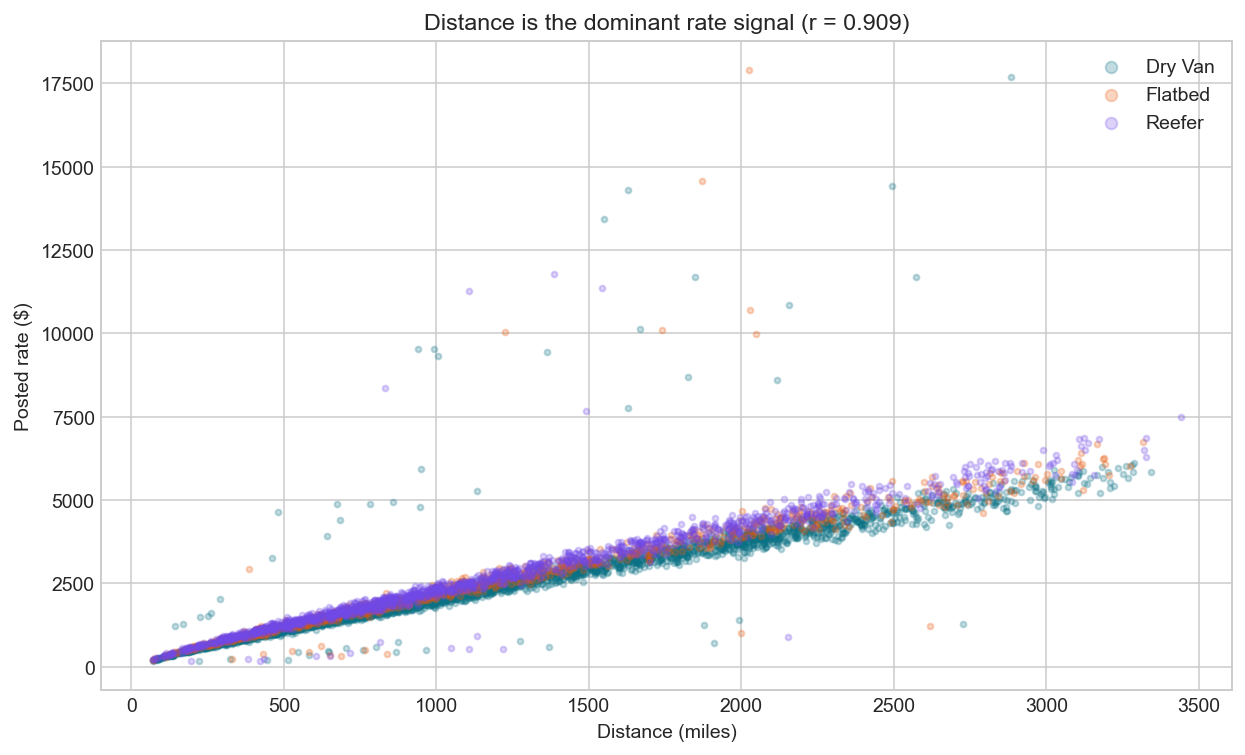

In [6]:
sample = data.sample(6000, random_state=42)
correlation = data[['distance', 'posted_rate']].corr().iloc[0, 1]
figure, axis = plt.subplots(figsize=(9, 5.5), dpi=140)
colors = {'Dry Van': '#0B7285', 'Flatbed': '#E8590C', 'Reefer': '#7048E8'}
for equipment, group in sample.groupby('equipment'):
    axis.scatter(group.distance, group.posted_rate, s=9, alpha=0.25, label=equipment, color=colors[equipment])
axis.set(title=f'Distance is the dominant rate signal (r = {correlation:.3f})', xlabel='Distance (miles)', ylabel='Posted rate ($)')
axis.legend(markerscale=2)
figure.tight_layout()
figure.savefig(REPORT / 'distance_vs_rate.png', bbox_inches='tight')
plt.show()

## Assemble assessment report

In [7]:
chart_files = [
    ('Rate-per-mile distribution', REPORT / 'rate_per_mile_distribution.png'),
    ('Monthly seasonality', REPORT / 'monthly_seasonality.png'),
    ('Equipment tiers', REPORT / 'equipment_rate_tiers.png'),
    ('Distance versus rate', REPORT / 'distance_vs_rate.png'),
    ('Model feature importance', REPORT / 'feature_importance.png'),
]
metrics_text = (REPORT / 'metrics.txt').read_text(encoding='utf-8') if (REPORT / 'metrics.txt').exists() else 'Run python src/train.py to generate metrics.'
with PdfPages(REPORT / 'report.pdf') as pdf:
    figure = plt.figure(figsize=(8.27, 11.69))
    figure.text(0.08, 0.92, 'Freight Rate Prediction', fontsize=24, fontweight='bold', color='#064A56')
    figure.text(0.08, 0.875, 'Temporal validation and exploratory analysis', fontsize=14, color='#455A60')
    summary = (
        f'Dataset: {len(data):,} labeled loads, {data.date.min().date()} to {data.date.max().date()}\n'
        f'Distance-rate correlation: {correlation:.3f}\n'
        f'Median rate per mile: ${data.rate_per_mile.median():.2f}\n\n'
        'Cleaning: absolute weights; equipment-median weight imputation; date/month market-index imputation.\n'
        'Validation: Jan-Aug training, Sep-Oct temporal holdout.\n'
        'Model: native-categorical LightGBM trained on log1p(posted_rate).\n\n'
        + metrics_text
    )
    figure.text(0.08, 0.80, summary, fontsize=10.5, family='monospace', va='top', linespacing=1.55)
    pdf.savefig(figure, bbox_inches='tight')
    plt.close(figure)
    for title, image_path in chart_files:
        if not image_path.exists():
            continue
        image = plt.imread(image_path)
        figure, axis = plt.subplots(figsize=(11.69, 8.27))
        axis.imshow(image)
        axis.set_title(title, loc='left', fontsize=16, fontweight='bold')
        axis.axis('off')
        figure.tight_layout()
        pdf.savefig(figure, bbox_inches='tight')
        plt.close(figure)
print('Created report/report.pdf')

Created report/report.pdf
